### 动态扇入（fan-in）

**扇入（fan-in）**：多条分支汇聚到同一个节点。LangGraph 会等所有前驱分支在同一个
**superstep** 里完成后，才让汇聚节点**执行一次**，并把各分支的更新按 reducer 合并好。

- **静态扇入**：入边数量编译时固定（`add_edge` 写死，如 3 个分支都连到 `join`）。
- **动态扇入**：汇聚数量运行时才知道——`Send` 动态 fan-out 出 N 个 worker，
  每个 worker 把结果送回同一个汇总节点，**来几个收几个**。

下面用一个**词频统计**的 map-reduce 演示动态扇入，并用**字典 reducer** 汇总各分支的计数。

### 0. 公共导入

In [1]:
from typing import Annotated, Required, Sequence, NotRequired

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Send
from langchain_core.runnables import RunnableConfig
from IPython.display import Image, display


def show(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("跳过图形渲染：", e)
        print(graph.get_graph().draw_mermaid())

In [2]:
def merge_counts(left: dict[str, int], right: dict[str, int]) -> dict[str, int]:
    # left  = 已累积的值
    # right = 本次某个 worker 送回的增量
    return {k: left.get(k, 0) + right.get(k, 0) for k in left.keys() | right.keys()}


class PrivateState(MessagesState):
    item: Required[str]


class Input(MessagesState):
    items: Required[list[str]]


class Output(MessagesState):
    results: Annotated[dict[str, int], merge_counts]
    summary: NotRequired[str]

### 1. 字典 reducer 怎么写

各 worker 返回 `{"单词": 次数}`，需要把多个字典**按键累加**。注意三个坑：

1. **reducer 必须是模块级函数**（不能写成类方法）——`Annotated[..., reducer]` 在定义类体时
   就要引用它，而方法要等类建好才存在；
2. `Annotated[dict[str, int], merge_counts]` 第二个参数才是 reducer，**不能漏写**；
3. 累加时用 `.get(k, 0)`，否则只出现在某一侧的 key 会 `KeyError`。

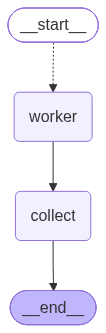

{'messages': [], 'results': {'apple': 2, 'cherry': 1, 'banana': 2}, 'summary': '共 3 个不同词，合计 5 次'}


In [3]:
def dispatch(state: Input) -> Sequence[Send]:
    return [Send("worker", {"item": item}) for item in state["items"]]


def worker(state: PrivateState) -> Output:
    words = state["item"].split(" ")
    # 统计每个单词的出现次数
    results = {}
    for word in words:
        results[word] = results.get(word, 0) + 1
    return {"results": results}


def collect(state: Output) -> Output:
    # fan-in 节点：在所有 worker 完成后只执行一次，可在这里做最终汇总
    total = sum(state["results"].values())
    return {"summary": f"共 {len(state['results'])} 个不同词，合计 {total} 次"}


builder = StateGraph(PrivateState, input_schema=Input, output_schema=Output)
builder.add_sequence([worker, collect])                      # dispatch 是路由函数，不是节点
builder.add_conditional_edges(START, dispatch, ["worker"])   # Send 的 path_map 用列表(pr((

graph = builder.compile()
show(graph)
result = graph.invoke({"items": ["apple apple", "banana banana", "cherry"]})
print(result)
